Loading dataframe from file 

In [1]:
import pandas as pd
df=pd.read_csv('../Data/Raw/spam.csv', encoding='latin-1')
print(df.shape)
df=df[['v1','v2']]
df.columns=['label','text']
print(df.head())

(5572, 5)
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


(Eda)Checking the Class balance 

In [2]:
df.label.value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

Checking for duplicates and missing values 

In [3]:
print(df.duplicated().sum())
print(df.isnull().sum())

403
label    0
text     0
dtype: int64


Creating a new cleaned dataframe (without duplicates)
Reason : duplicates in training data will creat an overfitting problem for my model and will cause a dataleakage if they are present in testing data  

In [4]:
df =df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(df.duplicated().sum())

0


Checking the intergrity of the data types 

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5169 entries, 0 to 5168
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5169 non-null   str  
 1   text    5169 non-null   str  
dtypes: str(2)
memory usage: 80.9 KB
None


Adding a length column to help me indentify spam and ham messages 

In [6]:
df['length']=df['text'].apply(len)
print(df.groupby('label')['length'].describe())

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0
spam    653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0


histogram

<Axes: >

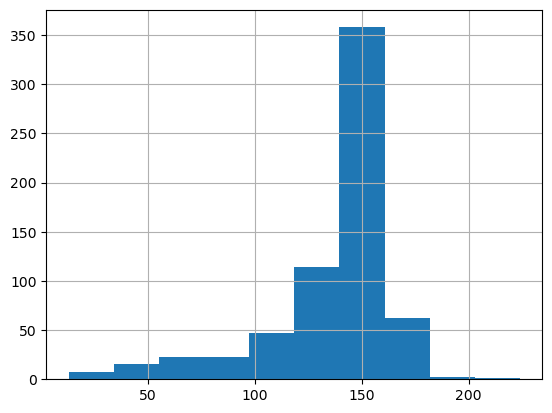

In [7]:
df[df.label=='spam']['length'].hist()

<Axes: >

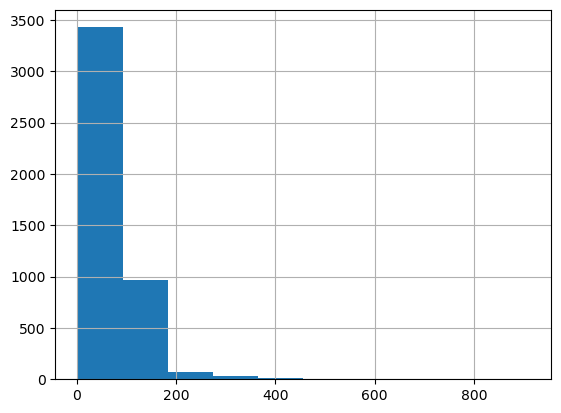

In [8]:
df[df.label=='ham']['length'].hist()

## Text Preprocessing
### 1. Cleaning 
**Operation** Removing uppercase letters, numbers and punctuation (!,.?)

In [9]:
df['text']=df['text'].str.lower()
df['text']=df['text'].str.replace(r'[0-9\W_]+', ' ', regex=True)

### 2. Tokenization 
**Operation** Removing stop_words (is,the...) and stemming the words (playing into play)
**Goal** This process simplifies the data (removing noise and keeping actual useful data) so that we can work on it

In [10]:
import nltk # this is an nlp toolkit
from nltk.corpus import stopwords # this is an object of a list of common words we can remove
from nltk.stem import PorterStemmer # this is the class of the objet that reduces words to their root form
nltk.download('stopwords') # the actual list

stemmer=PorterStemmer()
stop_words=set(stopwords.words('english'))
l_tokens=df['text'].str.split()
nl_tokens=[]
for tokens in l_tokens:
    tokens=[stemmer.stem(token) for token in tokens if token not in stop_words]
    nl_tokens.append(' '.join(tokens))
df['cleaned_text']=nl_tokens
#Comparing the original text and the cleaned text
print(  df['text'].head(),"\n")
print(df['cleaned_text'].head())

[nltk_data] Downloading package stopwords to /home/stayn/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0    go until jurong point crazy available only in ...
1                             ok lar joking wif u oni 
2    free entry in a wkly comp to win fa cup final ...
3         u dun say so early hor u c already then say 
4    nah i don t think he goes to usf he lives arou...
Name: text, dtype: str 

0    go jurong point crazi avail bugi n great world...
1                                ok lar joke wif u oni
2    free entri wkli comp win fa cup final tkt st m...
3                  u dun say earli hor u c alreadi say
4                 nah think goe usf live around though
Name: cleaned_text, dtype: str


## Feature Extraction (turning text into numbers)
### Tf-Idf vectorizer 
**Goal** Transforming text data into numerical one and exploring it

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(max_features=3000)
X=vectorizer.fit_transform(df['cleaned_text'])
print(X)



<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 37813 stored elements and shape (5169, 3000)>
  Coords	Values
  (0, 1066)	0.16146687088566894
  (0, 1940)	0.27657319329651747
  (0, 571)	0.312592656952489
  (0, 179)	0.3068747709825792
  (0, 349)	0.34130967818929053
  (0, 1098)	0.22592564389417463
  (0, 2926)	0.28247603281572625
  (0, 1399)	0.3267616085399272
  (0, 348)	0.3861173563308802
  (0, 467)	0.34130967818929053
  (0, 1085)	0.1892874331143361
  (0, 2839)	0.22369674017228175
  (1, 1802)	0.2848686019861351
  (1, 1411)	0.41888998866688537
  (1, 1350)	0.4801678856553941
  (1, 2887)	0.4431000927770725
  (1, 1811)	0.5625674771645618
  (2, 984)	0.1267804668687034
  (2, 817)	0.3935977182498594
  (2, 2910)	0.21760934653906108
  (2, 511)	0.21474783118866433
  (2, 2892)	0.16095350160140515
  (2, 876)	0.5318596038684652
  (2, 592)	0.2243088271059698
  (2, 929)	0.18462550436593325
  :	:
  (5164, 340)	0.3013345222032464
  (5164, 1625)	0.2756658154445352
  (5164, 766)	0.303152722606

## Saving the cleaned_Data into a csv file 

In [12]:
df.to_csv('../Data/Processed/spam_cleaned.csv', index=False)